In [19]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import glob

from scripts.postprocess import read_jsondir_to_df, to_complex
from scripts.postprocess import filter_df 

In [20]:
free_tol= 1e-6

In [21]:
# df = pd.read_json('data.json')
# df_filtered = filter_df(df, tol=1e-6)
# df_filtered.iloc[:]


In [37]:
path = "./data/muT_V15_prime"
df = read_jsondir_to_df(path)
df_filtered = filter_df(df, tol=1e-6)

df_filtered.iloc[600:640]

,mu,T,best_free,free,F_onsite,F_swave,F_dwave,F_px,F_py,Fuu_px,Fuu_py,Fdd_px,Fdd_py
600,0.081633,0.001000,-9232.451560,-9232.451560,0,0,0,0,0,"{'imag': -0.0342499472, 'real': 0.0377490929}","{'imag': 0.037650533800000004, 'real': 0.03416...","{'imag': -0.035059524, 'real': 0.0369564575000...","{'imag': 0.036904138600000004, 'real': 0.03500..."
601,0.081633,0.005125,-9232.451399,-9232.451399,0,0,0,0,0,"{'imag': -0.0342485857, 'real': 0.0377475923}","{'imag': 0.0376519031, 'real': 0.0341617664}","{'imag': -0.035058738900000004, 'real': 0.0369...","{'imag': 0.036904834500000004, 'real': 0.03501..."
602,0.081633,0.009250,-9232.413556,-9232.413556,0,0,0,0,0,"{'imag': -0.034234649900000004, 'real': 0.0377...","{'imag': 0.0376494883, 'real': 0.0341595754}","{'imag': -0.0350472149, 'real': 0.0369434824}","{'imag': 0.0368995585, 'real': 0.0350055456}"
603,0.081633,0.013375,-9232.223152,-9232.223152,0,0,0,0,0,"{'imag': -0.0341863948, 'real': 0.0376790477}","{'imag': 0.0376099472, 'real': 0.0341236996}","{'imag': -0.0350006888, 'real': 0.036894439}","{'imag': 0.0368577579, 'real': 0.0349658905}"
604,0.081633,0.017500,-9231.814499,-9231.814499,0,0,0,0,0,"{'imag': -0.0340863293, 'real': 0.0375687589}","{'imag': 0.0375111387, 'real': 0.0340340501000...","{'imag': -0.0349006368, 'real': 0.036788973600...","{'imag': 0.0367583866, 'real': 0.0348716198}"
605,0.081633,0.021625,-9231.173152,-9231.173152,0,0,0,0,0,"{'imag': -0.0339257669, 'real': 0.0373917927}","{'imag': 0.0373437134, 'real': 0.0338821443}","{'imag': -0.0347382093, 'real': 0.0366177577}","{'imag': 0.0365922354, 'real': 0.034713997}"
606,0.081633,0.025750,-9230.294676,-9230.294676,0,0,0,0,0,"{'imag': -0.0336985195, 'real': 0.0371413286}","{'imag': 0.037101147200000004, 'real': 0.03366...","{'imag': -0.0345071308, 'real': 0.0363741764}","{'imag': 0.036352846700000004, 'real': 0.03448..."
607,0.081633,0.029875,-9229.167014,-9229.167014,0,0,0,0,0,"{'imag': -0.0333972141, 'real': 0.0368092404}","{'imag': 0.036775595700000004, 'real': 0.03336...","{'imag': -0.0341999092, 'real': 0.0360503323}","{'imag': 0.0360324725, 'real': 0.0341829661}"
608,0.081633,0.034000,-9227.771060,-9227.771060,0,0,0,0,0,"{'imag': -0.0330128891, 'real': 0.0363856508}","{'imag': 0.0363574222, 'real': 0.0329872772}","{'imag': -0.0338074167, 'real': 0.0356366035}","{'imag': 0.035621618800000004, 'real': 0.03379..."
609,0.081633,0.038125,-9226.085352,-9226.085352,0,0,0,0,0,"{'imag': -0.0325354291, 'real': 0.035859411}","{'imag': 0.0358356763, 'real': 0.0325138944}","{'imag': -0.0333193346, 'real': 0.0351221133}","{'imag': 0.035109514, 'real': 0.033307382}"


In [23]:
import numpy as np
import pandas as pd

def canonical_phase_string_from_row(row, tol=1e-8):
    """
    Canonicalize the phase content of one row.

    Rules:
    1. real/imag parts are detected from F_onsite, F_swave, F_dwave, F_px, F_py
    2. phase + i phase -> phase   (e.g. d + id -> d)
    3. global phase rotations are discarded:
       choose the representative where the leftmost present component is real
    4. F_onsite and F_swave both map to 's'
    """

    # Canonical order
    bases = ["up_px", "up_py", "dn_px", "dn_py"]

    # Collect whether each base has real and/or imaginary part present
    comp = {b: {"r": False, "i": False} for b in bases}

    source_map = [
        ("Fuu_px", "up_px"),
        ("Fuu_py", "up_py"),
        ("Fdd_px", "dn_px"),
        ("Fdd_py", "dn_py"),
    ]

    for col, base in source_map:
        val = to_complex(row[col])
        if pd.isna(val):
            val = 0

        if np.abs(np.real(val)) > tol:
            comp[base]["r"] = True
        if np.abs(np.imag(val)) > tol:
            comp[base]["i"] = True

    # Rule 1: phase + i phase == phase
    # If both real and imag are present in same channel, collapse to just real representative.
    for b in bases:
        if comp[b]["r"] and comp[b]["i"]:
            comp[b]["i"] = False

    # Determine which channels are present at all
    present = [b for b in bases if comp[b]["r"] or comp[b]["i"]]
    if not present:
        return "normal"

    # Rule 2: remove global phase by forcing the leftmost present component to be real.
    # If leftmost present component is imaginary-only, multiply everything by -i:
    # real <-> imag for presence purposes.
    left = present[0]
    if comp[left]["i"] and not comp[left]["r"]:
        rotated = {b: {"r": False, "i": False} for b in bases}
        for b in bases:
            # Under multiplication by -i: real presence -> imag presence, imag presence -> real presence
            rotated[b]["r"] = comp[b]["i"]
            rotated[b]["i"] = comp[b]["r"]
        comp = rotated

        # After rotation, again collapse phase + i phase -> phase
        for b in bases:
            if comp[b]["r"] and comp[b]["i"]:
                comp[b]["i"] = False

    # Build canonical ordered label
    labels = []
    for b in bases:
        if comp[b]["r"]:
            labels.append(b)
        elif comp[b]["i"]:
            labels.append("i" + b)

    return " + ".join(labels) if labels else "normal"

In [24]:
df_phase = df_filtered.copy()
df_phase["phase"] = df_phase.apply(canonical_phase_string_from_row, axis=1)

In [25]:
df_phase["min_free_at_point"] = df_phase.groupby(["mu", "T"])["free"].transform("min")

df_deg = df_phase[
    np.abs(df_phase["free"] - df_phase["min_free_at_point"]) <= free_tol
].copy()

In [26]:
def combine_degenerate_phases(phases):
    return " | ".join(sorted(set(phases)))

df_plot = (
    df_deg.groupby(["mu", "T"], as_index=False)
    .agg(
        phase=("phase", combine_degenerate_phases),
        free=("free", "min"),
    )
)

In [27]:
phase_order = sorted(df_plot["phase"].unique())
phase_to_id = {phase: i for i, phase in enumerate(phase_order)}
id_to_phase = {i: phase for phase, i in phase_to_id.items()}

df_plot["phase_id"] = df_plot["phase"].map(phase_to_id)

phase_grid = df_plot.pivot(index="T", columns="mu", values="phase_id").sort_index()

In [28]:
phase_grid_filled = phase_grid.ffill(axis=0)

In [29]:
T_vals = phase_grid_filled.index.to_numpy()
mu_vals = phase_grid_filled.columns.to_numpy()
Z = phase_grid_filled.to_numpy()

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def cell_edges(vals):
    vals = np.asarray(vals)
    if len(vals) == 1:
        d = 0.5
        return np.array([vals[0] - d, vals[0] + d])
    mids = 0.5 * (vals[:-1] + vals[1:])
    left = vals[0] - 0.5 * (vals[1] - vals[0])
    right = vals[-1] + 0.5 * (vals[-1] - vals[-2])
    return np.concatenate([[left], mids, [right]])

def plot_phase_boundaries_from_grid(mu_vals, T_vals, Z, linewidth=1.5):
    mu_edges = cell_edges(mu_vals)
    T_edges = cell_edges(T_vals)

    fig, ax = plt.subplots(figsize=(8, 6))
    nT, nmu = Z.shape

    # vertical interfaces
    for j in range(nT):
        for i in range(nmu - 1):
            z1 = Z[j, i]
            z2 = Z[j, i + 1]
            if np.isnan(z1) or np.isnan(z2):
                continue
            if z1 != z2:
                x = mu_edges[i + 1]
                ax.plot([x, x], [T_edges[j], T_edges[j + 1]], linewidth=linewidth)

    # horizontal interfaces
    for j in range(nT - 1):
        for i in range(nmu):
            z1 = Z[j, i]
            z2 = Z[j + 1, i]
            if np.isnan(z1) or np.isnan(z2):
                continue
            if z1 != z2:
                y = T_edges[j + 1]
                ax.plot([mu_edges[i], mu_edges[i + 1]], [y, y], linewidth=linewidth)

    ax.set_xlim(mu_edges[0], mu_edges[-1])
    ax.set_ylim(T_edges[0], T_edges[-1])
    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel("T")
    ax.set_title("Phase boundaries")
    plt.tight_layout()
    plt.show()

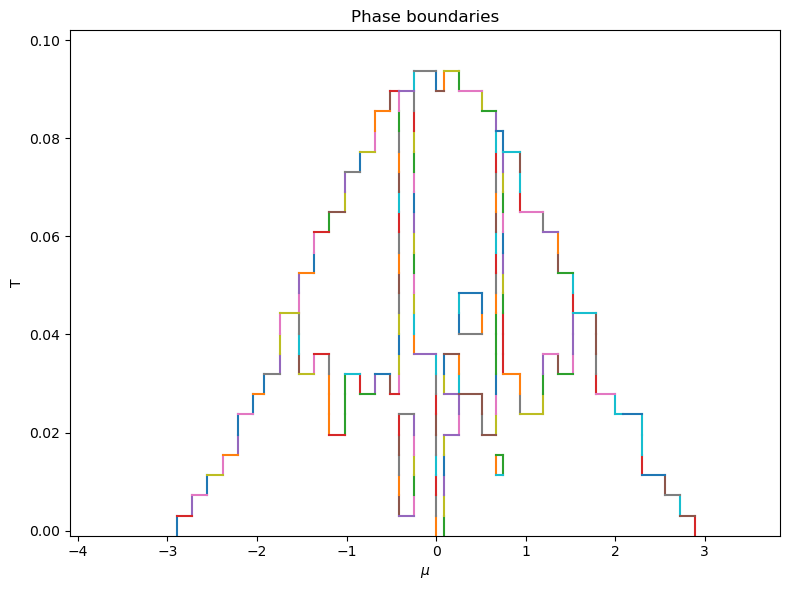

In [31]:
plot_phase_boundaries_from_grid(mu_vals, T_vals, Z)

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def boundary_points_from_grid(mu_vals, T_vals, Z):
    mu_vals = np.asarray(mu_vals)
    T_vals = np.asarray(T_vals)
    Z = np.asarray(Z)

    nT, nmu = Z.shape
    pts = []

    # phase changes between neighboring mu cells
    for j in range(nT):
        for i in range(nmu - 1):
            z1 = Z[j, i]
            z2 = Z[j, i + 1]
            if np.isnan(z1) or np.isnan(z2):
                continue
            if z1 != z2:
                x = 0.5 * (mu_vals[i] + mu_vals[i + 1])
                y = T_vals[j]
                pts.append((x, y))

    # phase changes between neighboring T cells
    for j in range(nT - 1):
        for i in range(nmu):
            z1 = Z[j, i]
            z2 = Z[j + 1, i]
            if np.isnan(z1) or np.isnan(z2):
                continue
            if z1 != z2:
                x = mu_vals[i]
                y = 0.5 * (T_vals[j] + T_vals[j + 1])
                pts.append((x, y))

    if not pts:
        return np.empty((0, 2))

    pts = np.array(pts, dtype=float)
    pts = np.unique(np.round(pts, 12), axis=0)
    return pts


def connected_components_points(pts, x_tol, y_tol):
    n = len(pts)
    if n == 0:
        return []

    visited = np.zeros(n, dtype=bool)
    components = []

    for start in range(n):
        if visited[start]:
            continue

        stack = [start]
        visited[start] = True
        comp = []

        while stack:
            i = stack.pop()
            comp.append(i)

            dx = np.abs(pts[:, 0] - pts[i, 0])
            dy = np.abs(pts[:, 1] - pts[i, 1])

            neighbors = np.where((dx <= x_tol) & (dy <= y_tol))[0]
            for j in neighbors:
                if not visited[j]:
                    visited[j] = True
                    stack.append(j)

        components.append(pts[comp])

    return components


def sort_branch(branch):
    # choose the dominant spread direction
    dx = np.ptp(branch[:, 0])
    dy = np.ptp(branch[:, 1])

    if dx >= dy:
        return branch[np.argsort(branch[:, 0])]
    else:
        return branch[np.argsort(branch[:, 1])]


def plot_phase_boundaries_as_lines(mu_vals, T_vals, Z, linewidth=1.5, markersize=1):
    mu_vals = np.asarray(mu_vals)
    T_vals = np.asarray(T_vals)
    Z = np.asarray(Z)

    pts = boundary_points_from_grid(mu_vals, T_vals, Z)

    fig, ax = plt.subplots(figsize=(8, 6))

    # optional: show original grid points
    MU, TT = np.meshgrid(mu_vals, T_vals)
    # ax.plot(MU.ravel(), TT.ravel(), '.', color='lightgray', markersize=2)

    if len(pts) > 0:
        dmu = np.min(np.diff(np.unique(mu_vals))) if len(mu_vals) > 1 else 1.0
        dT  = np.min(np.diff(np.unique(T_vals))) if len(T_vals) > 1 else 1.0

        comps = connected_components_points(
            pts,
            x_tol=0.75 * dmu,
            y_tol=0.75 * dT
        )

        for comp in comps:
            if len(comp) == 1:
                ax.plot(comp[:, 0], comp[:, 1], 'o', color='black', markersize=markersize)
            else:
                comp = sort_branch(comp)
                ax.plot(
                    comp[:, 0], comp[:, 1],
                    '-o',
                    color='black',
                    linewidth=linewidth,
                    markersize=markersize
                )

    ax.set_xlabel(r'$\mu$')
    ax.set_ylabel(r'$T$')
    ax.set_title('Phase boundaries')
    plt.tight_layout()
    plt.show()

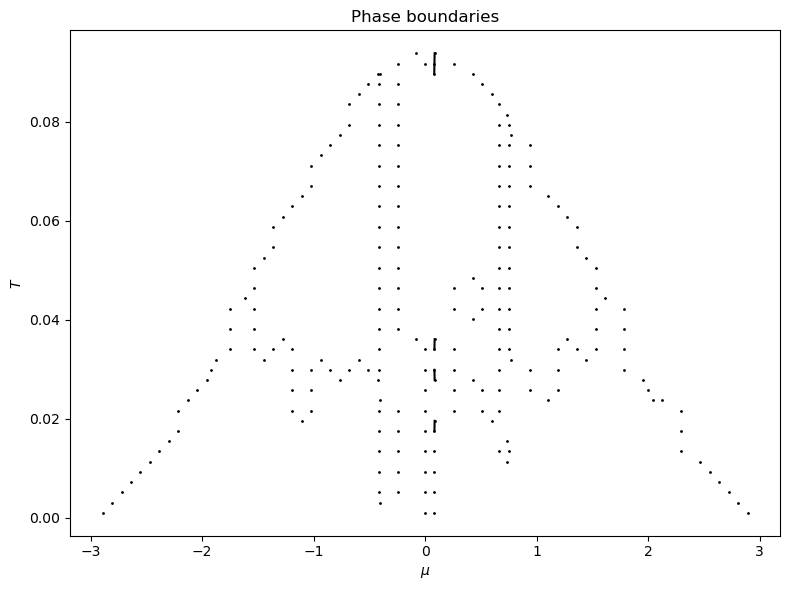

In [33]:
plot_phase_boundaries_as_lines(mu_vals, T_vals, Z)

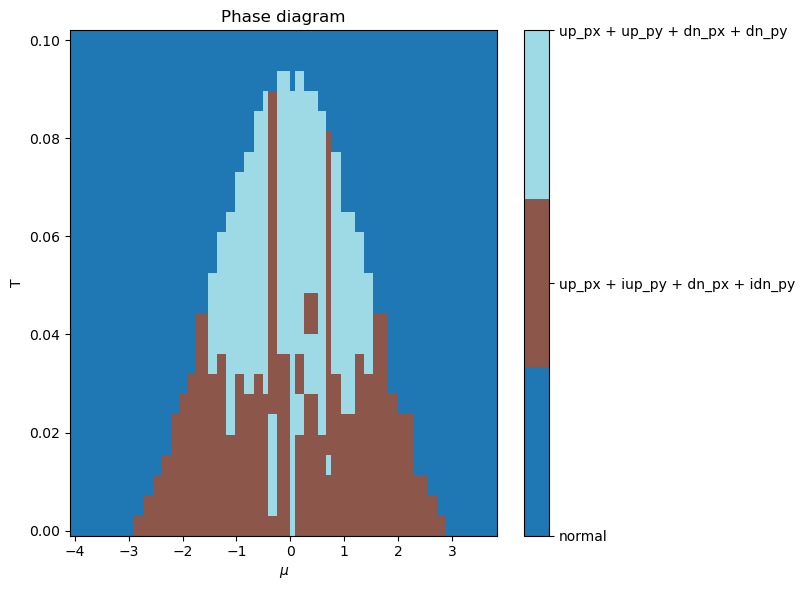

In [34]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(plt.cm.tab20(np.linspace(0, 1, len(phase_order))))

plt.figure(figsize=(8, 6))
mesh = plt.pcolormesh(mu_vals, T_vals, Z, shading="nearest", cmap=cmap)

cbar = plt.colorbar(mesh, ticks=np.arange(len(phase_order)))
cbar.ax.set_yticklabels(phase_order)

plt.xlabel(r"$\mu$")
plt.ylabel("T")
plt.title("Phase diagram")
# plt.ylim(0.01,0.3)
plt.tight_layout()
plt.show()

### REVIEW RAW
Postprocess mistakenly classifies px + ipy + ipx + py as px + py

In [35]:
raw_df = pd.read_json("./data/muT_V15_prime/raw/results_0020.json")

In [36]:
raw_df.iloc[-10:]

,mu,temp,seed,free_energy,Fuu_px,Fuu_py,Fdd_px,Fdd_py
165,-0.595745,0.095875,dd:px+ipy,-17124.379122,"{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}","{'imag': 1.1844791249999999e-23, 'real': 0.0}","{'imag': 0.0, 'real': -1.1844716e-23}"
166,-0.595745,0.095875,uu+dd:px+py,-17124.379122,"{'imag': 0.0, 'real': 0.0}","{'imag': -0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}","{'imag': -0.0, 'real': 0.0}"
167,-0.595745,0.095875,uu+dd:px+ipy,-17124.379122,"{'imag': -3.271677889e-19, 'real': 0.0}","{'imag': 0.0, 'real': 3.231526104e-19}","{'imag': 7.637380774e-20, 'real': 0.0}","{'imag': 0.0, 'real': 2.9013481209999994e-20}"
168,-0.595745,0.100000,normal state,-17128.937303,"{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}"
169,-0.595745,0.100000,uu:px+py,-17128.937303,"{'imag': 0.0, 'real': 0.0}","{'imag': -0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}"
170,-0.595745,0.100000,uu:px+ipy,-17128.937303,"{'imag': -6.165869102e-19, 'real': 0.0}","{'imag': 0.0, 'real': 1.3440805039999998e-20}","{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}"
171,-0.595745,0.100000,dd:px+py,-17128.937303,"{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}","{'imag': -0.0, 'real': 0.0}"
172,-0.595745,0.100000,dd:px+ipy,-17128.937303,"{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}","{'imag': 9.078614771e-24, 'real': 0.0}","{'imag': 0.0, 'real': -9.078561532e-24}"
173,-0.595745,0.100000,uu+dd:px+py,-17128.937303,"{'imag': 0.0, 'real': 0.0}","{'imag': -0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}","{'imag': -0.0, 'real': 0.0}"
174,-0.595745,0.100000,uu+dd:px+ipy,-17128.937303,"{'imag': 6.014352964e-20, 'real': 0.0}","{'imag': 0.0, 'real': 5.648543617e-20}","{'imag': 1.1663175850000001e-19, 'real': 0.0}","{'imag': 0.0, 'real': 7.943129273e-20}"
